In [1]:
from transformers import AutoTokenizer
import torch

# 加载Minimax 2.5 tokenizer
tokenizer = AutoTokenizer.from_pretrained("MiniMaxAI/MiniMax-M2.5")

/app/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Minimax M2.5词表大小:", tokenizer.vocab_size)

# 测试句子
text = "马嘉祺马嘉棋马嘉|祺马јект马嘉诚马佳琦马星驰"

# 编码
tokens = tokenizer(text, return_tensors="pt")
print("Token IDs:", tokens['input_ids'])

# 逐个解码Token ID
print("单个Token解码结果:")
for token_id in tokens['input_ids'][0]:
    decoded = tokenizer.decode([token_id])
    print(f"ID {token_id}: {decoded}")

# 完整解码
detokenized_text = tokenizer.decode(tokens['input_ids'][0])
print("完整解码结果:", detokenized_text)

Minimax M2.5词表大小: 200000
Token IDs: tensor([[  4143, 190467,   4143,  17050,  29789,   4143,  17050,    124,  95095,
           4143, 188214,   4143,  17050,  13043,   4143,  11041,  70519,   4143,
         177085]])
单个Token解码结果:
ID 4143: 马
ID 190467: 嘉祺
ID 4143: 马
ID 17050: 嘉
ID 29789: 棋
ID 4143: 马
ID 17050: 嘉
ID 124: |
ID 95095: 祺
ID 4143: 马
ID 188214: јект
ID 4143: 马
ID 17050: 嘉
ID 13043: 诚
ID 4143: 马
ID 11041: 佳
ID 70519: 琦
ID 4143: 马
ID 177085: 星驰
完整解码结果: 马嘉祺马嘉棋马嘉|祺马јект马嘉诚马佳琦马星驰


In [3]:
from functools import lru_cache
# GPT-2 ByteLevel BPE mapping (bytes_to_unicode) + roundtrip demo

@lru_cache
def bytes_to_unicode():
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1
    return dict(zip(bs, map(chr, cs)))

@lru_cache
def unicode_to_bytes():
    btou = bytes_to_unicode()
    return {v: k for k, v in btou.items()}

def bytelevel_encode(text):
    btou = bytes_to_unicode()
    return "".join(btou[b] for b in text.encode("utf-8"))

def bytelevel_decode_bytes(encoded):
    utob = unicode_to_bytes()
    return bytes(utob[ch] for ch in encoded)

def bytelevel_decode(encoded, errors="strict"):
    return bytelevel_decode_bytes(encoded).decode("utf-8", errors=errors)

def safe_token_text(token):
    try:
        return bytelevel_decode(token)
    except (UnicodeDecodeError, KeyError):
        return token

# --- encode ---
text = "嘉祺"
utf8_bytes = text.encode("utf-8")  # e5 98 89 e7 a5 ba
btou = bytes_to_unicode()
encoded = "".join(btou[b] for b in utf8_bytes)

print("utf8 bytes hex:", utf8_bytes.hex(" "))
print("bytelevel encoded:", encoded)

# --- decode ---
decoded_bytes = bytelevel_decode_bytes(encoded)
decoded_text = decoded_bytes.decode("utf-8")

print("decoded bytes hex:", decoded_bytes.hex(" "))
print("decoded text:", decoded_text)

utf8 bytes hex: e5 98 89 e7 a5 ba
bytelevel encoded: åĺīç¥º
decoded bytes hex: e5 98 89 e7 a5 ba
decoded text: 嘉祺


In [4]:
# 优先使用 tokenizer 的完整词表；它会包含 added tokens / special tokens
vocab = tokenizer.get_vocab()
reverse_vocab = {v: safe_token_text(k) for k, v in vocab.items()}

# 某些 tokenizer 会把特殊 token 单独维护，这里再补一层，避免出现 <missing:...>
for token, token_id in tokenizer.get_added_vocab().items():
    reverse_vocab[token_id] = token

for token_id in getattr(tokenizer, "all_special_ids", []):
    reverse_vocab.setdefault(token_id, tokenizer.convert_ids_to_tokens(token_id))

reverse_vocab[190467]

'嘉祺'

In [5]:
from huggingface_hub import hf_hub_download
# 替换为实际模型名称，如 "MiniMaxAI/MiniMax-M1"
model_name = "MiniMaxAI/MiniMax-M2.5"
config_path = hf_hub_download(repo_id=model_name, filename="model.safetensors.index.json")
# "lm_head.weight": "model-00124-of-00126.safetensors"
# "model.embed_tokens.weight": "model-00000-of-00126.safetensors"
# 容器外运行 modelscope download --model MiniMax/MiniMax-M2.5 model-00124-of-00126.safetensors model-00000-of-00126.safetensors --local_dir ~/.cache/huggingface/hub/models--MiniMaxAI--MiniMax-M2.5/snapshots/f710177d938eff80b684d42c5aa84b382612f21f/

## lm_head 模长分析

In [6]:
from safetensors import safe_open
weight_path_base = "/root/.cache/huggingface/hub/models--MiniMaxAI--MiniMax-M2.5/snapshots/f710177d938eff80b684d42c5aa84b382612f21f/"
# 用内存映射模式打开，不加载全量到内存
with safe_open(weight_path_base+"model-00124-of-00126.safetensors", framework="pt", device="cpu") as f:
    # 获取 lm_head 权重张量的形状
    lm_head = f.get_tensor("lm_head.weight")
    print(f"lm_head 形状: {lm_head.shape}")


lm_head 形状: torch.Size([200064, 3072])


In [10]:
import torch
# 计算 lm_head 200064 个行的 norm 并排序，然后打印前/后 10 的对应行数和模长，
lm_head_norms = lm_head.norm(dim=1)
sorted_norms, sorted_indices = torch.sort(lm_head_norms, descending=True)
print("前 10 行的 norm 排序:")
for i in range(10):
    print(f"行索引: {sorted_indices[i].item()}, 模长: {sorted_norms[i].item()}")
print("...")
print("后 10 行的 norm 排序:")
for i in range(1,11):
    print(f"行索引: {sorted_indices[-i].item()}, 模长: {sorted_norms[-i].item()}")
# 打印 lm_head 190467 行的模长，和排名
jq_rank = torch.where(sorted_indices == 190467)
jq_norm = sorted_norms[jq_rank]
print(f"lm_head 190467 行的模长: {jq_norm[0]}, 排名: {jq_rank[0][0]}")


前 10 行的 norm 排序:
行索引: 74541, 模长: 1.9296875
行索引: 93905, 模长: 1.8984375
行索引: 69635, 模长: 1.84375
行索引: 200034, 模长: 1.828125
行索引: 110712, 模长: 1.75
行索引: 88530, 模长: 1.7265625
行索引: 196954, 模长: 1.703125
行索引: 43013, 模长: 1.6875
行索引: 137081, 模长: 1.6875
行索引: 88628, 模长: 1.6796875
...
后 10 行的 norm 排序:
行索引: 121365, 模长: 0.455078125
行索引: 44259, 模长: 0.4765625
行索引: 63626, 模长: 0.484375
行索引: 76353, 模长: 0.490234375
行索引: 26502, 模长: 0.4921875
行索引: 18569, 模长: 0.4921875
行索引: 7168, 模长: 0.49609375
行索引: 23998, 模长: 0.498046875
行索引: 11357, 模长: 0.498046875
行索引: 51516, 模长: 0.5
lm_head 190467 行的模长: 1.0078125, 排名: 55266


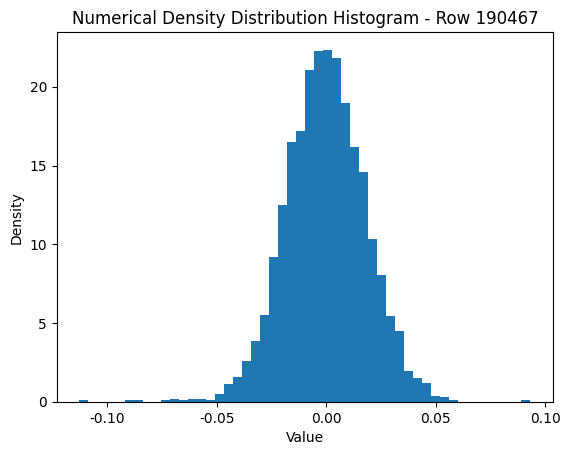

In [69]:
# 画出 190467 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 190467 行向量的数值，BFloat16->Float16
vector_190467 = lm_head[190467].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(vector_190467, bins=50, density=True)
plt.title("Numerical Density Distribution Histogram - Row 190467")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

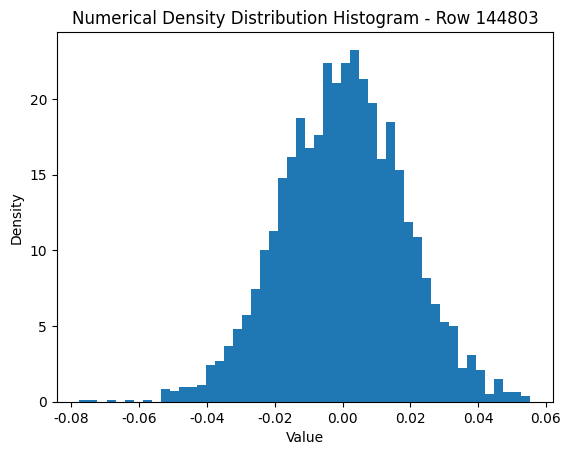

In [ ]:
# 画出 144803 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 144803 行向量的数值，BFloat16->Float16
vector_144803 = lm_head[144803].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(vector_144803, bins=50, density=True)
plt.title("Numerical Density Distribution Histogram - Row 144803")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

In [ ]:
for i in (list(range(55260, 55271))):
    print(f"行索引: {sorted_indices[i].item()}, 模长: {sorted_norms[i].item()}，排名: {i}")

# 177085: 星驰
jq_rank_177085 = torch.where(sorted_indices == 177085)
jq_norm_177085 = sorted_norms[jq_rank_177085]
print(f"177085 行的模长: {jq_norm_177085[0]}, 排名: {jq_rank_177085[0][0]}")


行索引: 64389, 模长: 1.0078125，排名: 55260
行索引: 106211, 模长: 1.0078125，排名: 55261
行索引: 88961, 模长: 1.0078125，排名: 55262
行索引: 79755, 模长: 1.0078125，排名: 55263
行索引: 18722, 模长: 1.0078125，排名: 55264
行索引: 144803, 模长: 1.0078125，排名: 55265
行索引: 190467, 模长: 1.0078125，排名: 55266
行索引: 127123, 模长: 1.0078125，排名: 55267
行索引: 140509, 模长: 1.0078125，排名: 55268
行索引: 156037, 模长: 1.0078125，排名: 55269
行索引: 105931, 模长: 1.0078125，排名: 55270
177085 行的模长: 1.1015625, 排名: 19130


## lm_head 相似度分析

In [16]:
# 计算第 190467 行的向量与其它行向量的相似度，倒序排序，输出 top 20 的相似度和对应的行索引
import torch

target_row = 190467
target_vector = lm_head[target_row]

def token_text(row_idx):
    if row_idx in reverse_vocab:
        return reverse_vocab[row_idx]
    token = tokenizer.convert_ids_to_tokens(row_idx)
    if token is None:
        return f"<missing:{row_idx}>"
    decoded = safe_token_text(token)
    reverse_vocab[row_idx] = decoded
    return decoded

similarities = torch.cosine_similarity(lm_head, target_vector.unsqueeze(0), dim=1)
top_20_indices = similarities.argsort(descending=True)[:20]

print(f"target 行索引: {target_row}, token: {repr(token_text(target_row))}")
print("top 20:")
for i in top_20_indices:
    print(f"行索引: {i.item()}, token: {repr(token_text(i.item()))}, 相似度: {similarities[i].item()}")

print("bottom 10:")
bottom_10_indices = similarities.argsort(descending=False)[:10]
for i in bottom_10_indices:
    print(f"行索引: {i.item()}, token: {repr(token_text(i.item()))}, 相似度: {similarities[i].item()}")

average_similarity = similarities.mean().item()
print(f"平均相似度: {average_similarity}")



target 行索引: 190467, token: '嘉祺'
top 20:
行索引: 190467, token: '嘉祺', 相似度: 1.0
行索引: 198631, token: 'EFCFFF', 相似度: 0.486328125
行索引: 36850, token: '”،', 相似度: 0.484375
行索引: 103921, token: 'LENBQUMs', 相似度: 0.4765625
行索引: 200042, token: '<repo_struct>', 相似度: 0.474609375
行索引: 120380, token: 'flagathlete', 相似度: 0.47265625
行索引: 168884, token: 'FBQzt', 相似度: 0.47265625
行索引: 154387, token: 'LEVBQUUs', 相似度: 0.470703125
行索引: 162600, token: '|電話番号', 相似度: 0.470703125
行索引: 178727, token: '\\"`*"]\n', 相似度: 0.46875
行索引: 115860, token: '|Squadra', 相似度: 0.46484375
行索引: 180328, token: 'otingar', 相似度: 0.46484375
行索引: 111520, token: 'robotskapad', 相似度: 0.46484375
行索引: 255, token: 'ÿ', 相似度: 0.46484375
行索引: 200056, token: '<missing:200056>', 相似度: 0.46484375
行索引: 99097, token: '|titolo', 相似度: 0.46484375
行索引: 200023, token: '<code_interpreter>', 相似度: 0.462890625
行索引: 200043, token: '<code_context>', 相似度: 0.462890625
行索引: 200027, token: ']<]start of speech[>[', 相似度: 0.462890625
行索引: 92954, token: '=mtgcardfetcher', 相

In [8]:
lm_head.shape

torch.Size([200064, 3072])

## embedding 相似度分析

In [7]:
from safetensors import safe_open
weight_path_base = "/root/.cache/huggingface/hub/models--MiniMaxAI--MiniMax-M2.5/snapshots/f710177d938eff80b684d42c5aa84b382612f21f/"
# 用内存映射模式打开，不加载全量到内存
with safe_open(weight_path_base+"model-00000-of-00126.safetensors", framework="pt", device="cpu") as f:
    # 获取 Embedding 权重张量的形状
    embedding = f.get_tensor("model.embed_tokens.weight")
    print(f"Embedding 形状: {embedding.shape}")


Embedding 形状: torch.Size([200064, 3072])


In [70]:
# 计算第 190467 行的向量与其它行向量的相似度，倒序排序，输出 top 10 的相似度和对应的行索引
import torch
# 提取第 190467 行的向量
target_vector = embedding[190467]
# 计算相似度
similarities = torch.cosine_similarity(embedding, target_vector.unsqueeze(0), dim=1)
# 倒序排序，获取 top 20 的索引
top_20_indices = similarities.argsort(descending=True)[:20]
# 输出 top 20 的相似度和对应的行索引
for i in top_20_indices:
    print(f"行索引: {i.item()}, 相似度: {similarities[i].item()}")  

# 输出 bottom 10 的相似度和对应的行索引
print("bottom 10:")
bottom_10_indices = similarities.argsort(descending=False)[:10]
for i in bottom_10_indices:
    print(f"行索引: {i.item()}, 相似度: {similarities[i].item()}")  

# 计算平均相似度
average_similarity = similarities.mean().item()
print(f"平均相似度: {average_similarity}")

# 找到 177085 行的相似度
similarity_177085 = similarities[177085].item()
print(f"177085 行的相似度: {similarity_177085}")


行索引: 190467, 相似度: 1.0
行索引: 183969, 相似度: 0.365234375
行索引: 198538, 相似度: 0.322265625
行索引: 95095, 相似度: 0.306640625
行索引: 198118, 相似度: 0.30078125
行索引: 17050, 相似度: 0.26953125
行索引: 197234, 相似度: 0.25390625
行索引: 183851, 相似度: 0.251953125
行索引: 56314, 相似度: 0.25
行索引: 73501, 相似度: 0.2421875
行索引: 96696, 相似度: 0.2412109375
行索引: 186194, 相似度: 0.240234375
行索引: 41302, 相似度: 0.236328125
行索引: 177085, 相似度: 0.232421875
行索引: 145898, 相似度: 0.2314453125
行索引: 181063, 相似度: 0.2265625
行索引: 22892, 相似度: 0.2255859375
行索引: 194743, 相似度: 0.2236328125
行索引: 196531, 相似度: 0.220703125
行索引: 187121, 相似度: 0.220703125
bottom 10:
行索引: 20106, 相似度: -0.1494140625
行索引: 13952, 相似度: -0.1474609375
行索引: 123957, 相似度: -0.1416015625
行索引: 26064, 相似度: -0.1396484375
行索引: 17783, 相似度: -0.1328125
行索引: 77149, 相似度: -0.1318359375
行索引: 43979, 相似度: -0.1298828125
行索引: 3382, 相似度: -0.12890625
行索引: 34321, 相似度: -0.12890625
行索引: 28522, 相似度: -0.125
平均相似度: 0.01373291015625
177085 行的相似度: 0.232421875


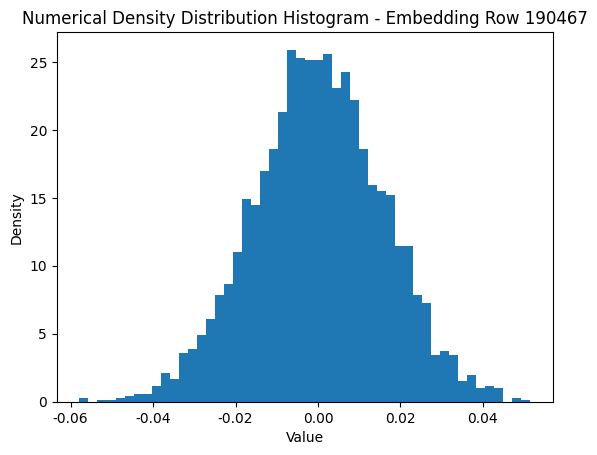

In [64]:
# 画出 190467 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 190467 行向量的数值，BFloat16->Float16
emb_vector_190467 = embedding[196954].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(emb_vector_190467, bins=50, density=True)  
plt.title("Numerical Density Distribution Histogram - Embedding Row 190467")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

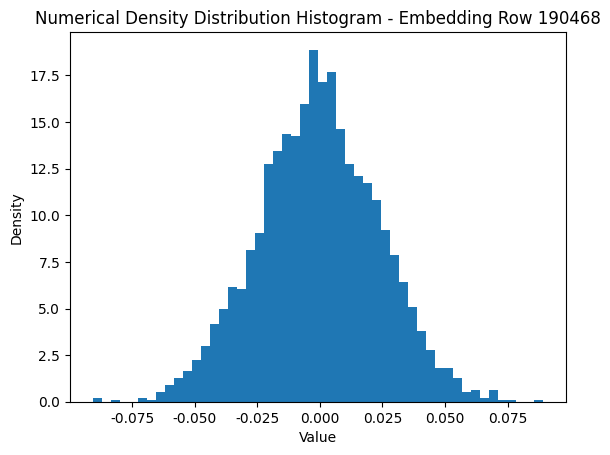

In [66]:
# 画出 190468 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 190468 行向量的数值，BFloat16->Float16
emb_vector_190468 = embedding[190468].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(emb_vector_190468, bins=50, density=True)  
plt.title("Numerical Density Distribution Histogram - Embedding Row 190468")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

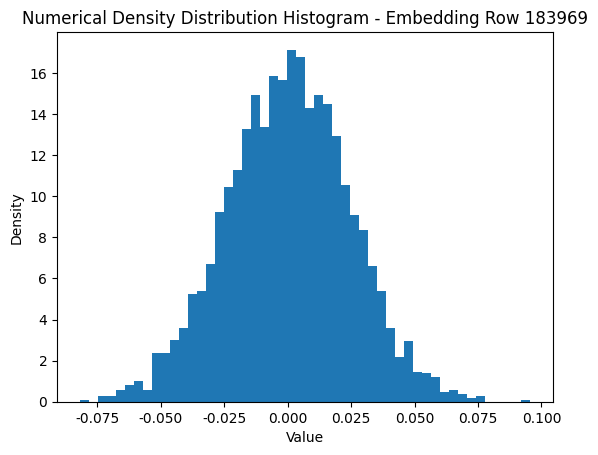

In [67]:
# 画出 183969 行向量的数值密度分布
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']  # 使用系统可用的无衬线字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 提取 183969 行向量的数值，BFloat16->Float16
emb_vector_183969 = embedding[183969].float().cpu().numpy()

# 绘制数值密度分布直方图
plt.hist(emb_vector_183969, bins=50, density=True)  
plt.title("Numerical Density Distribution Histogram - Embedding Row 183969")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

## embedding 和 lm_head 的行的相似性分析


In [61]:
# embedding 和 lm_head 的行的相似性
import torch

# 计算相似度
similarities = torch.cosine_similarity(embedding, lm_head, dim=1)

# 全局倒序排序
sorted_indices = similarities.argsort(descending=True)
sorted_similarities = similarities[sorted_indices]

# 输出 top 10 的索引和相似度
for i in range(10):
    print(f"行索引: {sorted_indices[i].item()}, 相似度: {sorted_similarities[i].item()}")

# 输出 bottom 10 的索引和相似度
for i in range(10):
    print(f"行索引: {sorted_indices[-i-1].item()}, 相似度: {sorted_similarities[-i-1].item()}")

# 输出第 190467 行的索引和相似度和排名
print("第 190467 行的相似性分析:")
print(f"行索引: {190467}, 相似度: {similarities[190467].item()}, 排名: {sorted_indices.tolist().index(190467)+1}")


行索引: 142520, 相似度: 0.0751953125
行索引: 150963, 相似度: 0.07421875
行索引: 198929, 相似度: 0.07421875
行索引: 97861, 相似度: 0.0732421875
行索引: 49334, 相似度: 0.0732421875
行索引: 109394, 相似度: 0.0732421875
行索引: 53979, 相似度: 0.072265625
行索引: 144714, 相似度: 0.072265625
行索引: 106099, 相似度: 0.0712890625
行索引: 100510, 相似度: 0.0703125
行索引: 20455, 相似度: -0.0888671875
行索引: 4096, 相似度: -0.0888671875
行索引: 29180, 相似度: -0.08251953125
行索引: 18274, 相似度: -0.08251953125
行索引: 1544, 相似度: -0.08251953125
行索引: 12643, 相似度: -0.08203125
行索引: 10206, 相似度: -0.08154296875
行索引: 15528, 相似度: -0.080078125
行索引: 101494, 相似度: -0.07958984375
行索引: 27686, 相似度: -0.07958984375
第 190467 行的相似性分析:
行索引: 190467, 相似度: -0.010009765625, 排名: 125210


In [11]:
# embedding 和 lm_head 的模长差异
import torch

# 计算模长
embedding_norms = torch.norm(embedding, dim=1)
lm_head_norms = torch.norm(lm_head, dim=1)

# 计算差异
norm_diffs = embedding_norms - lm_head_norms

# 全局排序
sorted_indices = norm_diffs.argsort(descending=True)
sorted_diffs = norm_diffs[sorted_indices]

# 输出 top 10 的索引和差异
for i in range(10):
    print(f"行索引: {sorted_indices[i].item()}, 差异: {sorted_diffs[i].item()}")

# 输出 bottom 10 的索引和差异
for i in range(10):
    print(f"行索引: {sorted_indices[-i-1].item()}, 差异: {sorted_diffs[-i-1].item()}")

# 输出第 190467 行的索引和差异和排名
print("第 190467 行的模长差异分析:")
print(f"行索引: {190467}, 差异: {norm_diffs[190467].item()}, 排名: {sorted_indices.tolist().index(190467)+1}, embedding 模长: {embedding_norms[190467].item()}, lm_head 模长: {lm_head_norms[190467].item()}")


行索引: 200021, 差异: 2.421875
行索引: 163627, 差异: 0.875
行索引: 200018, 差异: 0.84765625
行索引: 121365, 差异: 0.828125
行索引: 160030, 差异: 0.796875
行索引: 112077, 差异: 0.7890625
行索引: 200007, 差异: 0.78515625
行索引: 178461, 差异: 0.78125
行索引: 66020, 差异: 0.78125
行索引: 144665, 差异: 0.77734375
行索引: 254, 差异: -1.4921875
行索引: 253, 差异: -1.4921875
行索引: 193720, 差异: -1.4921875
行索引: 251, 差异: -1.4921875
行索引: 200055, 差异: -1.4921875
行索引: 200057, 差异: -1.4921875
行索引: 200059, 差异: -1.4921875
行索引: 245, 差异: -1.4921875
行索引: 193, 差异: -1.4921875
行索引: 200054, 差异: -1.4921875
第 190467 行的模长差异分析:
行索引: 190467, 差异: 0.3125, 排名: 145684, embedding 模长: 1.3203125, lm_head 模长: 1.0078125


## token 子集 + metric MDS

这个版本的子集选择目标是：

- 必含全部 `token_id >= 200000` 的 token
- 必含异常 token `190467`
- 补入异常簇核心近邻
- 再补少量非 special 的近簇控制点和远端背景点
- 总数控制在 `1000` 以内，适合 CPU 做两两距离和 MDS


,token_id,token,family,point_type,center_sim,tier
992,200056,<missing:200056>,Tooling / Multimodal Specials,special token,0.978209,core
13,255,ÿ,Multilingual Boilerplate / Reference Fragments,matched control,0.978191,core
968,200032,<end of video>,Tooling / Multimodal Specials,special token,0.977982,core
964,200028,<end of speech>,Tooling / Multimodal Specials,special token,0.977884,core
963,200027,<start of speech>,Tooling / Multimodal Specials,special token,0.977861,core
966,200030,<end of image>,Tooling / Multimodal Specials,special token,0.977816,core
994,200058,<missing:200058>,Tooling / Multimodal Specials,special token,0.977801,core
979,200043,<code_context>,Tooling / Multimodal Specials,special token,0.977764,core
967,200031,<start of video>,Tooling / Multimodal Specials,special token,0.977752,core
999,200063,<missing:200063>,Tooling / Multimodal Specials,special token,0.977662,core


plot token count: 1000
mandatory high-id token count: 64


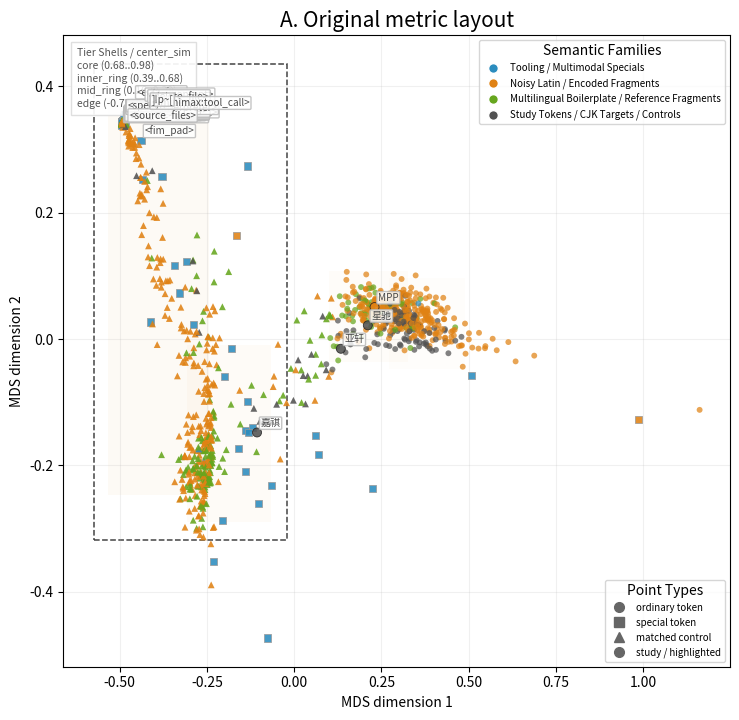

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

# 方法 A: 动态设置 (推荐，最稳妥)
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'WenQuanYi Micro Hei'] # 优先级从前往后
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题

MAX_PLOT_TOKENS = 1000
ANOMALY_TOKEN_ID = 190467
MANDATORY_HIGH_IDS = [idx for idx in range(lm_head.shape[0]) if idx >= 200000]
MANDATORY_IDS = set(MANDATORY_HIGH_IDS + [ANOMALY_TOKEN_ID, 177085, 190468, 183969])

def normalize_token_text(token):
    token = str(token)
    if token.startswith("]<]") and token.endswith("[>["):
        return f"<{token[3:-3]}>"
    return token

def lm_topk_neighbors(row_idx, k=64):
    sims = torch.cosine_similarity(lm_head, lm_head[row_idx].unsqueeze(0), dim=1)
    order = sims.argsort(descending=True)
    order = order[order != row_idx][:k]
    return [idx.item() for idx in order], sims

def classify_family(token):
    token = normalize_token_text(token)
    lowered = token.lower()
    if any(key in lowered for key in ['speech', 'image', 'video', 'vision', 'code_', 'review_', 'pr_', 'source_', 'file', 'interpreter', 'fim_']):
        return 'Tooling / Multimodal Specials'
    if token.startswith('<') and token.endswith('>'):
        return 'Tooling / Multimodal Specials'
    if any(ch in token for ch in ['|', '\\', '/', '=', '+']) or token.isascii() and len(token) >= 8:
        return 'Noisy Latin / Encoded Fragments'
    if any('\u4e00' <= ch <= '\u9fff' for ch in token):
        return 'Study Tokens / CJK Targets / Controls'
    if any(ord(ch) > 127 for ch in token):
        return 'Multilingual Boilerplate / Reference Fragments'
    return 'Noisy Latin / Encoded Fragments'

anomaly_neighbor_ids, anomaly_sims = lm_topk_neighbors(ANOMALY_TOKEN_ID, k=220)

cluster_seed_ids = sorted(set(
    [ANOMALY_TOKEN_ID] +
    MANDATORY_HIGH_IDS +
    anomaly_neighbor_ids[:120]
))

lm_head_unit = torch.nn.functional.normalize(lm_head.float(), dim=1)
cluster_centroid = torch.nn.functional.normalize(lm_head_unit[cluster_seed_ids].mean(dim=0, keepdim=True), dim=1)[0]
center_sims_all = torch.matmul(lm_head_unit, cluster_centroid)

selected_ids = set(MANDATORY_IDS)
selected_ids.update(cluster_seed_ids)
selected_ids.update(anomaly_neighbor_ids[:180])

non_special_ids = [
    idx for idx in center_sims_all.argsort(descending=True).tolist()
    if idx not in selected_ids
]
selected_ids.update(non_special_ids[:260])

remaining_budget = MAX_PLOT_TOKENS - len(selected_ids)
if remaining_budget > 0:
    far_ids = [
        idx for idx in center_sims_all.argsort(descending=False).tolist()
        if idx not in selected_ids
    ]
    stride = max(1, len(far_ids) // remaining_budget)
    selected_ids.update(far_ids[::stride][:remaining_budget])

plot_ids = sorted(selected_ids)
if len(plot_ids) > MAX_PLOT_TOKENS:
    must_keep = sorted(MANDATORY_IDS | set(anomaly_neighbor_ids[:180]))
    must_keep = [idx for idx in must_keep if idx in selected_ids]
    leftovers = [idx for idx in plot_ids if idx not in set(must_keep)]
    plot_ids = must_keep + leftovers[:MAX_PLOT_TOKENS - len(must_keep)]
    plot_ids = sorted(set(plot_ids))

plot_ids = plot_ids[:MAX_PLOT_TOKENS]
plot_id_set = set(plot_ids)
plot_cluster_seed_ids = [idx for idx in cluster_seed_ids if idx in plot_id_set]

plot_rows = []
for idx in plot_ids:
    token = normalize_token_text(token_text(idx))
    family = classify_family(token)
    is_special = idx >= 200000
    is_study = idx in {ANOMALY_TOKEN_ID, 177085, 190468, 183969}
    is_control = (not is_special) and (center_sims_all[idx].item() > float(center_sims_all[ANOMALY_TOKEN_ID].item()) - 0.18)
    point_type = 'ordinary token'
    if is_special:
        point_type = 'special token'
    if is_control:
        point_type = 'matched control'
    if is_study:
        point_type = 'study / highlighted'
    plot_rows.append({
        'token_id': idx,
        'token': token,
        'family': family,
        'point_type': point_type,
        'center_sim': float(center_sims_all[idx].item()),
        'is_special_like': bool(is_special),
        'is_cluster_seed': idx in plot_cluster_seed_ids,
    })

left_plot_df = pd.DataFrame(plot_rows)
tier_labels = ['edge', 'mid_ring', 'inner_ring', 'core']
left_plot_df['tier'] = pd.qcut(left_plot_df['center_sim'], q=4, labels=tier_labels, duplicates='drop')
left_plot_df['tier'] = left_plot_df['tier'].astype(str)

plot_vectors = lm_head_unit[plot_ids]
dist = torch.cdist(plot_vectors, plot_vectors, p=2).cpu().numpy()

def classical_mds(distance_matrix, n_components=2):
    d2 = distance_matrix ** 2
    n = d2.shape[0]
    j = np.eye(n) - np.ones((n, n)) / n
    b = -0.5 * j @ d2 @ j
    eigvals, eigvecs = np.linalg.eigh(b)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    pos = np.maximum(eigvals[:n_components], 0)
    coords = eigvecs[:, :n_components] * np.sqrt(pos)
    return coords

coords = classical_mds(dist, n_components=2)
left_plot_df['x'] = coords[:, 0]
left_plot_df['y'] = coords[:, 1]

cluster_points = left_plot_df[left_plot_df['is_cluster_seed']].copy()
x0, x1 = cluster_points['x'].quantile([0.05, 0.95]).tolist()
y0, y1 = cluster_points['y'].quantile([0.05, 0.95]).tolist()
pad_x = max(0.08, (x1 - x0) * 0.12)
pad_y = max(0.08, (y1 - y0) * 0.12)

family_colors = {
    'Tooling / Multimodal Specials': '#2b8cbe',
    'Noisy Latin / Encoded Fragments': '#e08214',
    'Multilingual Boilerplate / Reference Fragments': '#66a61e',
    'Study Tokens / CJK Targets / Controls': '#525252',
}
point_markers = {
    'ordinary token': 'o',
    'special token': 's',
    'matched control': '^',
    'study / highlighted': 'o',
}
point_sizes = {
    'ordinary token': 18,
    'special token': 26,
    'matched control': 24,
    'study / highlighted': 42,
}
point_edge = {
    'ordinary token': 'none',
    'special token': '#999999',
    'matched control': 'none',
    'study / highlighted': '#222222',
}

fig, ax = plt.subplots(figsize=(8.6, 8.2))

shell_order = ['edge', 'mid_ring', 'inner_ring', 'core']
shell_alpha = {'edge': 0.05, 'mid_ring': 0.08, 'inner_ring': 0.10, 'core': 0.13}
for tier in shell_order:
    shell_df = left_plot_df[left_plot_df['tier'] == tier]
    if len(shell_df) < 8:
        continue
    sx0, sx1 = shell_df['x'].quantile([0.12, 0.88]).tolist()
    sy0, sy1 = shell_df['y'].quantile([0.12, 0.88]).tolist()
    ax.add_patch(Rectangle(
        (sx0 - 0.04, sy0 - 0.04),
        (sx1 - sx0) + 0.08,
        (sy1 - sy0) + 0.08,
        facecolor='#f6d9b8',
        edgecolor='none',
        alpha=shell_alpha[tier],
        zorder=0,
    ))

ax.add_patch(Rectangle(
    (x0 - pad_x, y0 - pad_y),
    (x1 - x0) + 2 * pad_x,
    (y1 - y0) + 2 * pad_y,
    fill=False,
    linestyle='--',
    linewidth=1.1,
    edgecolor='#444444',
    zorder=1,
))

for point_type, marker in point_markers.items():
    sub = left_plot_df[left_plot_df['point_type'] == point_type]
    if sub.empty:
        continue
    colors = sub['family'].map(family_colors)
    ax.scatter(
        sub['x'],
        sub['y'],
        c=colors,
        s=point_sizes[point_type],
        marker=marker,
        alpha=0.88 if point_type != 'ordinary token' else 0.72,
        edgecolors=point_edge[point_type],
        linewidths=0.6 if point_edge[point_type] != 'none' else 0.0,
        zorder=3 if point_type != 'ordinary token' else 2,
    )

label_candidates = left_plot_df[
    left_plot_df['token_id'].isin(MANDATORY_IDS) |
    (left_plot_df['center_sim'] >= left_plot_df['center_sim'].quantile(0.97))
].copy()
label_candidates = label_candidates.sort_values(['point_type', 'center_sim'], ascending=[False, False]).drop_duplicates('token').head(36)
for _, row in label_candidates.iterrows():
    ax.text(
        row['x'] + 0.01,
        row['y'] + 0.01,
        row['token'],
        fontsize=7.2,
        color='#4a4a4a',
        bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='#bbbbbb', alpha=0.85),
        zorder=4,
    )

tier_ranges = []
for tier in shell_order[::-1]:
    vals = left_plot_df.loc[left_plot_df['tier'] == tier, 'center_sim']
    if len(vals) == 0:
        continue
    tier_ranges.append(f"{tier} ({vals.min():.2f}..{vals.max():.2f})")
tier_text = 'Tier Shells / center_sim\n' + '\n'.join(tier_ranges)
ax.text(
    0.02, 0.98, tier_text,
    transform=ax.transAxes,
    ha='left', va='top', fontsize=7.5, color='#555555',
    bbox=dict(facecolor='white', edgecolor='#dddddd', alpha=0.92)
)

family_handles = [
    Line2D([0], [0], marker='o', color='w', label=family, markerfacecolor=color, markersize=7)
    for family, color in family_colors.items()
]
point_handles = [
    Line2D([0], [0], marker=point_markers[name], color='#666666', linestyle='None', label=name, markersize=7)
    for name in ['ordinary token', 'special token', 'matched control', 'study / highlighted']
]
legend1 = ax.legend(handles=family_handles, loc='upper right', title='Semantic Families', frameon=True, fontsize=7)
ax.add_artist(legend1)
ax.legend(handles=point_handles, loc='lower right', title='Point Types', frameon=True, fontsize=7)

ax.set_title('A. Original metric layout', fontsize=15)
ax.set_xlabel('MDS dimension 1')
ax.set_ylabel('MDS dimension 2')
ax.grid(alpha=0.18)

display(left_plot_df[['token_id', 'token', 'family', 'point_type', 'center_sim', 'tier']].sort_values('center_sim', ascending=False).head(40))
print(f'plot token count: {len(left_plot_df)}')
print(f'mandatory high-id token count: {len([idx for idx in plot_ids if idx >= 200000])}')
plt.show()


/app/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Minimax M2.5词表大小: 200000
Token IDs: tensor([[  4143, 190467,   4143,  17050,  29789,   4143,  17050,    124,  95095,
           4143, 188214,   4143,  17050,  13043,   4143,  11041,  70519,   4143,
         177085]])
单个Token解码结果:
ID 4143: 马
ID 190467: 嘉祺
ID 4143: 马
ID 17050: 嘉
ID 29789: 棋
ID 4143: 马
ID 17050: 嘉
ID 124: |
ID 95095: 祺
ID 4143: 马
ID 188214: јект
ID 4143: 马
ID 17050: 嘉
ID 13043: 诚
ID 4143: 马
ID 11041: 佳
ID 70519: 琦
ID 4143: 马
ID 177085: 星驰
完整解码结果: 马嘉祺马嘉棋马嘉|祺马јект马嘉诚马佳琦马星驰
utf8 bytes hex: e5 98 89 e7 a5 ba
bytelevel encoded: åĺīç¥º
decoded bytes hex: e5 98 89 e7 a5 ba
decoded text: 嘉祺
嘉祺
lm_head 形状: torch.Size([200064, 3072])
前 10 行的 norm 排序:
行索引: 74541, 模长: 0.97265625
行索引: 93905, 模长: 0.94140625
行索引: 69635, 模长: 0.98046875
行索引: 200034, 模长: 0.5234375
行索引: 110712, 模长: 0.9140625
行索引: 88530, 模长: 0.94921875
行索引: 196954, 模长: 0.69921875
行索引: 43013, 模长: 1.03125
行索引: 137081, 模长: 0.875
行索引: 88628, 模长: 0.94921875
...
后 10 行的 norm 排序:
行索引: 51516, 模长: 1.015625
行索引: 11357, 模长: 1.1328125
行

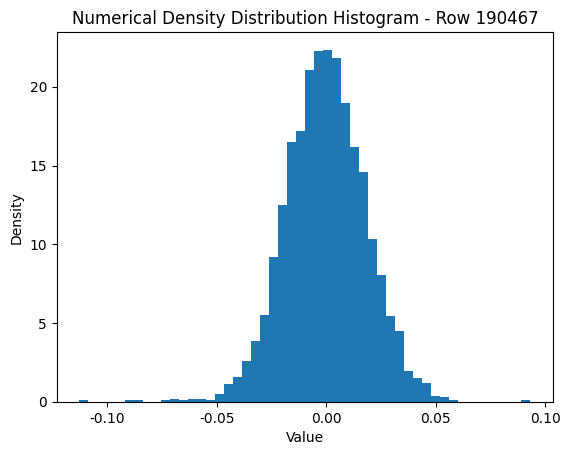

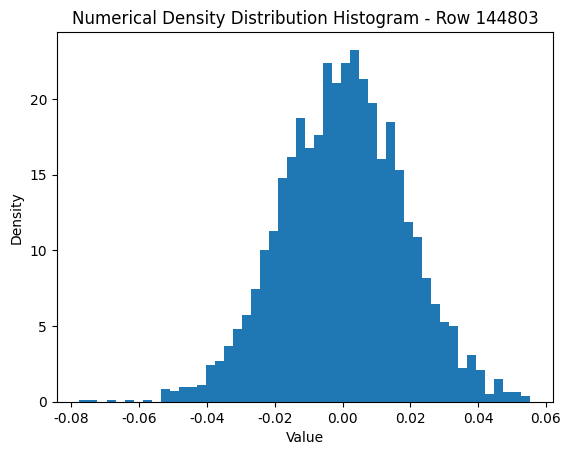

行索引: 64389, 模长: 1.0078125，排名: 55260
行索引: 106211, 模长: 1.0078125，排名: 55261
行索引: 88961, 模长: 1.0078125，排名: 55262
行索引: 79755, 模长: 1.0078125，排名: 55263
行索引: 18722, 模长: 1.0078125，排名: 55264
行索引: 144803, 模长: 1.0078125，排名: 55265
行索引: 190467, 模长: 1.0078125，排名: 55266
行索引: 127123, 模长: 1.0078125，排名: 55267
行索引: 140509, 模长: 1.0078125，排名: 55268
行索引: 156037, 模长: 1.0078125，排名: 55269
行索引: 105931, 模长: 1.0078125，排名: 55270
177085 行的模长: 1.1015625, 排名: 19130
target 行索引: 190467, token: '嘉祺'
top 20:
行索引: 190467, token: '嘉祺', 相似度: 1.0
行索引: 198631, token: 'EFCFFF', 相似度: 0.486328125
行索引: 36850, token: '”،', 相似度: 0.484375
行索引: 103921, token: 'LENBQUMs', 相似度: 0.4765625
行索引: 200042, token: '<repo_struct>', 相似度: 0.474609375
行索引: 120380, token: 'flagathlete', 相似度: 0.47265625
行索引: 168884, token: 'FBQzt', 相似度: 0.47265625
行索引: 154387, token: 'LEVBQUUs', 相似度: 0.470703125
行索引: 162600, token: '|電話番号', 相似度: 0.470703125
行索引: 178727, token: '\\"`*"]\n', 相似度: 0.46875
行索引: 115860, token: '|Squadra', 相似度: 0.46484375
行索引: 180328, tok

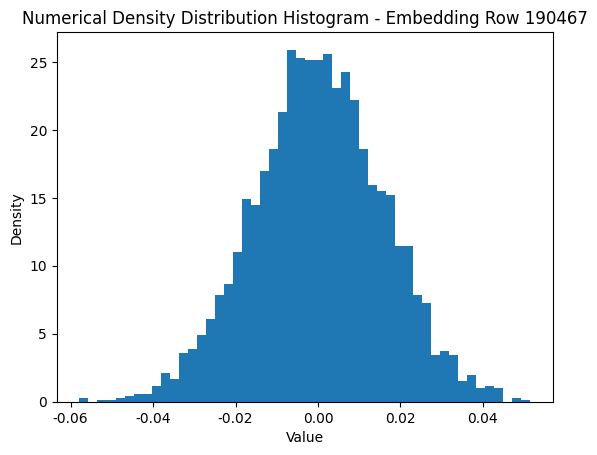

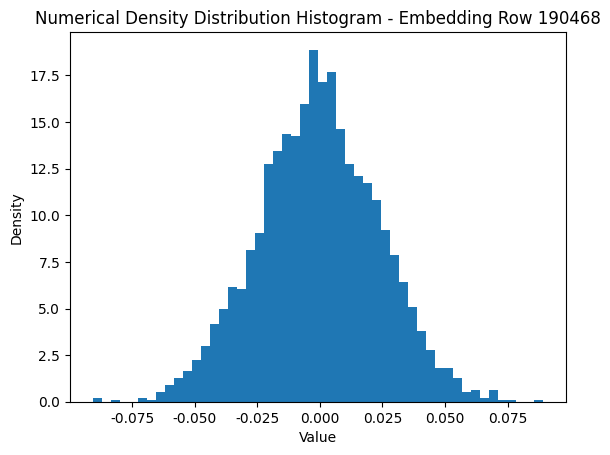

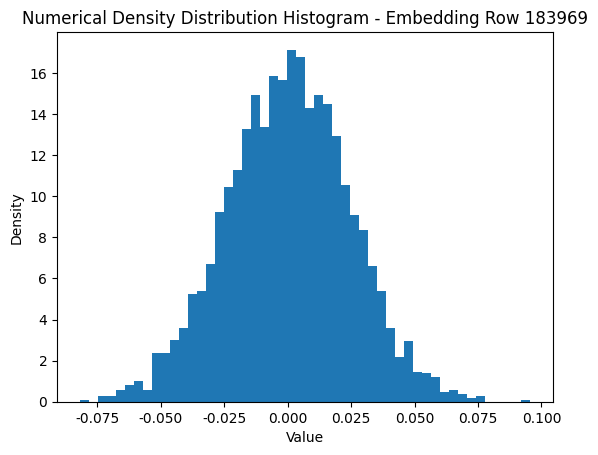

行索引: 142520, 相似度: 0.0751953125
行索引: 150963, 相似度: 0.07421875
行索引: 198929, 相似度: 0.07421875
行索引: 97861, 相似度: 0.0732421875
行索引: 49334, 相似度: 0.0732421875
行索引: 109394, 相似度: 0.0732421875
行索引: 53979, 相似度: 0.072265625
行索引: 144714, 相似度: 0.072265625
行索引: 106099, 相似度: 0.0712890625
行索引: 100510, 相似度: 0.0703125
行索引: 20455, 相似度: -0.0888671875
行索引: 4096, 相似度: -0.0888671875
行索引: 29180, 相似度: -0.08251953125
行索引: 18274, 相似度: -0.08251953125
行索引: 1544, 相似度: -0.08251953125
行索引: 12643, 相似度: -0.08203125
行索引: 10206, 相似度: -0.08154296875
行索引: 15528, 相似度: -0.080078125
行索引: 101494, 相似度: -0.07958984375
行索引: 27686, 相似度: -0.07958984375
第 190467 行的相似性分析:
行索引: 190467, 相似度: -0.010009765625, 排名: 125210
行索引: 200021, 差异: 2.421875
行索引: 163627, 差异: 0.875
行索引: 200018, 差异: 0.84765625
行索引: 121365, 差异: 0.828125
行索引: 160030, 差异: 0.796875
行索引: 112077, 差异: 0.7890625
行索引: 200007, 差异: 0.78515625
行索引: 178461, 差异: 0.78125
行索引: 66020, 差异: 0.78125
行索引: 144665, 差异: 0.77734375
行索引: 254, 差异: -1.4921875
行索引: 253, 差异: -1.4921875
行索引: 193720, 差异

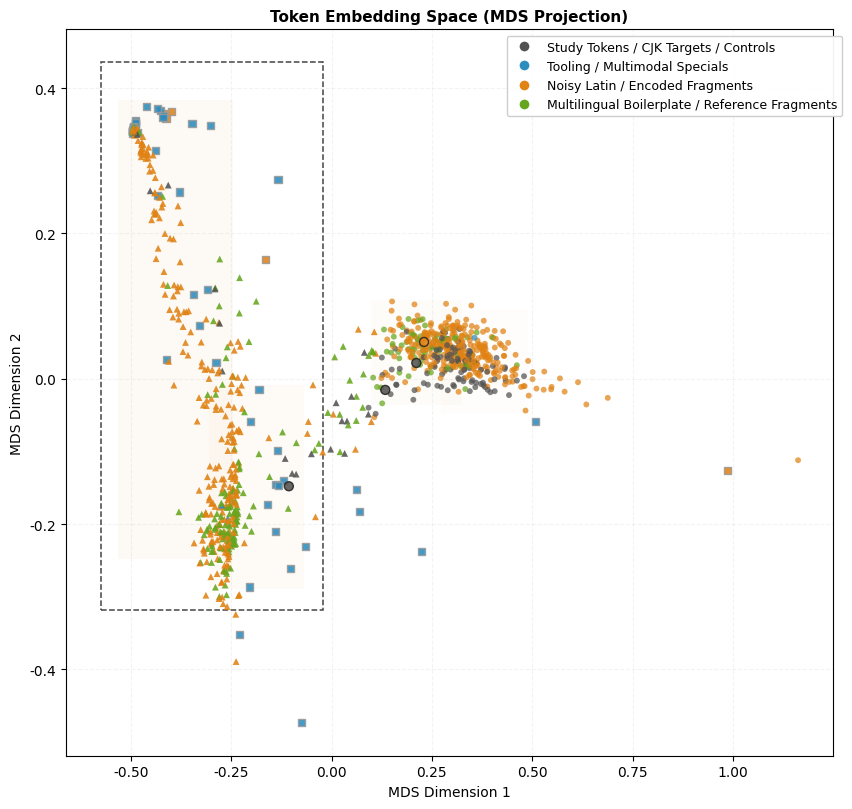